(299, 14)
   age_years sex_male_female  chest_pain_type  resting_bp_mmHg  \
0         63            Male   typical angina              145   
1         67            Male     asymptomatic              160   
2         67            Male     asymptomatic              120   
3         37            Male      non-anginal              130   
4         41          Female  atypical angina              130   

   serum_cholesterol_mgdl  fasting_blood_sugar_gt120 resting_ecg_result  \
0                     233                       True     lv hypertrophy   
1                     286                      False     lv hypertrophy   
2                     229                      False     lv hypertrophy   
3                     250                      False             normal   
4                     204                      False     lv hypertrophy   

   thalch  exercise_induced_angina  st_depression_exercise  \
0     150                    False                     2.3   
1     108         

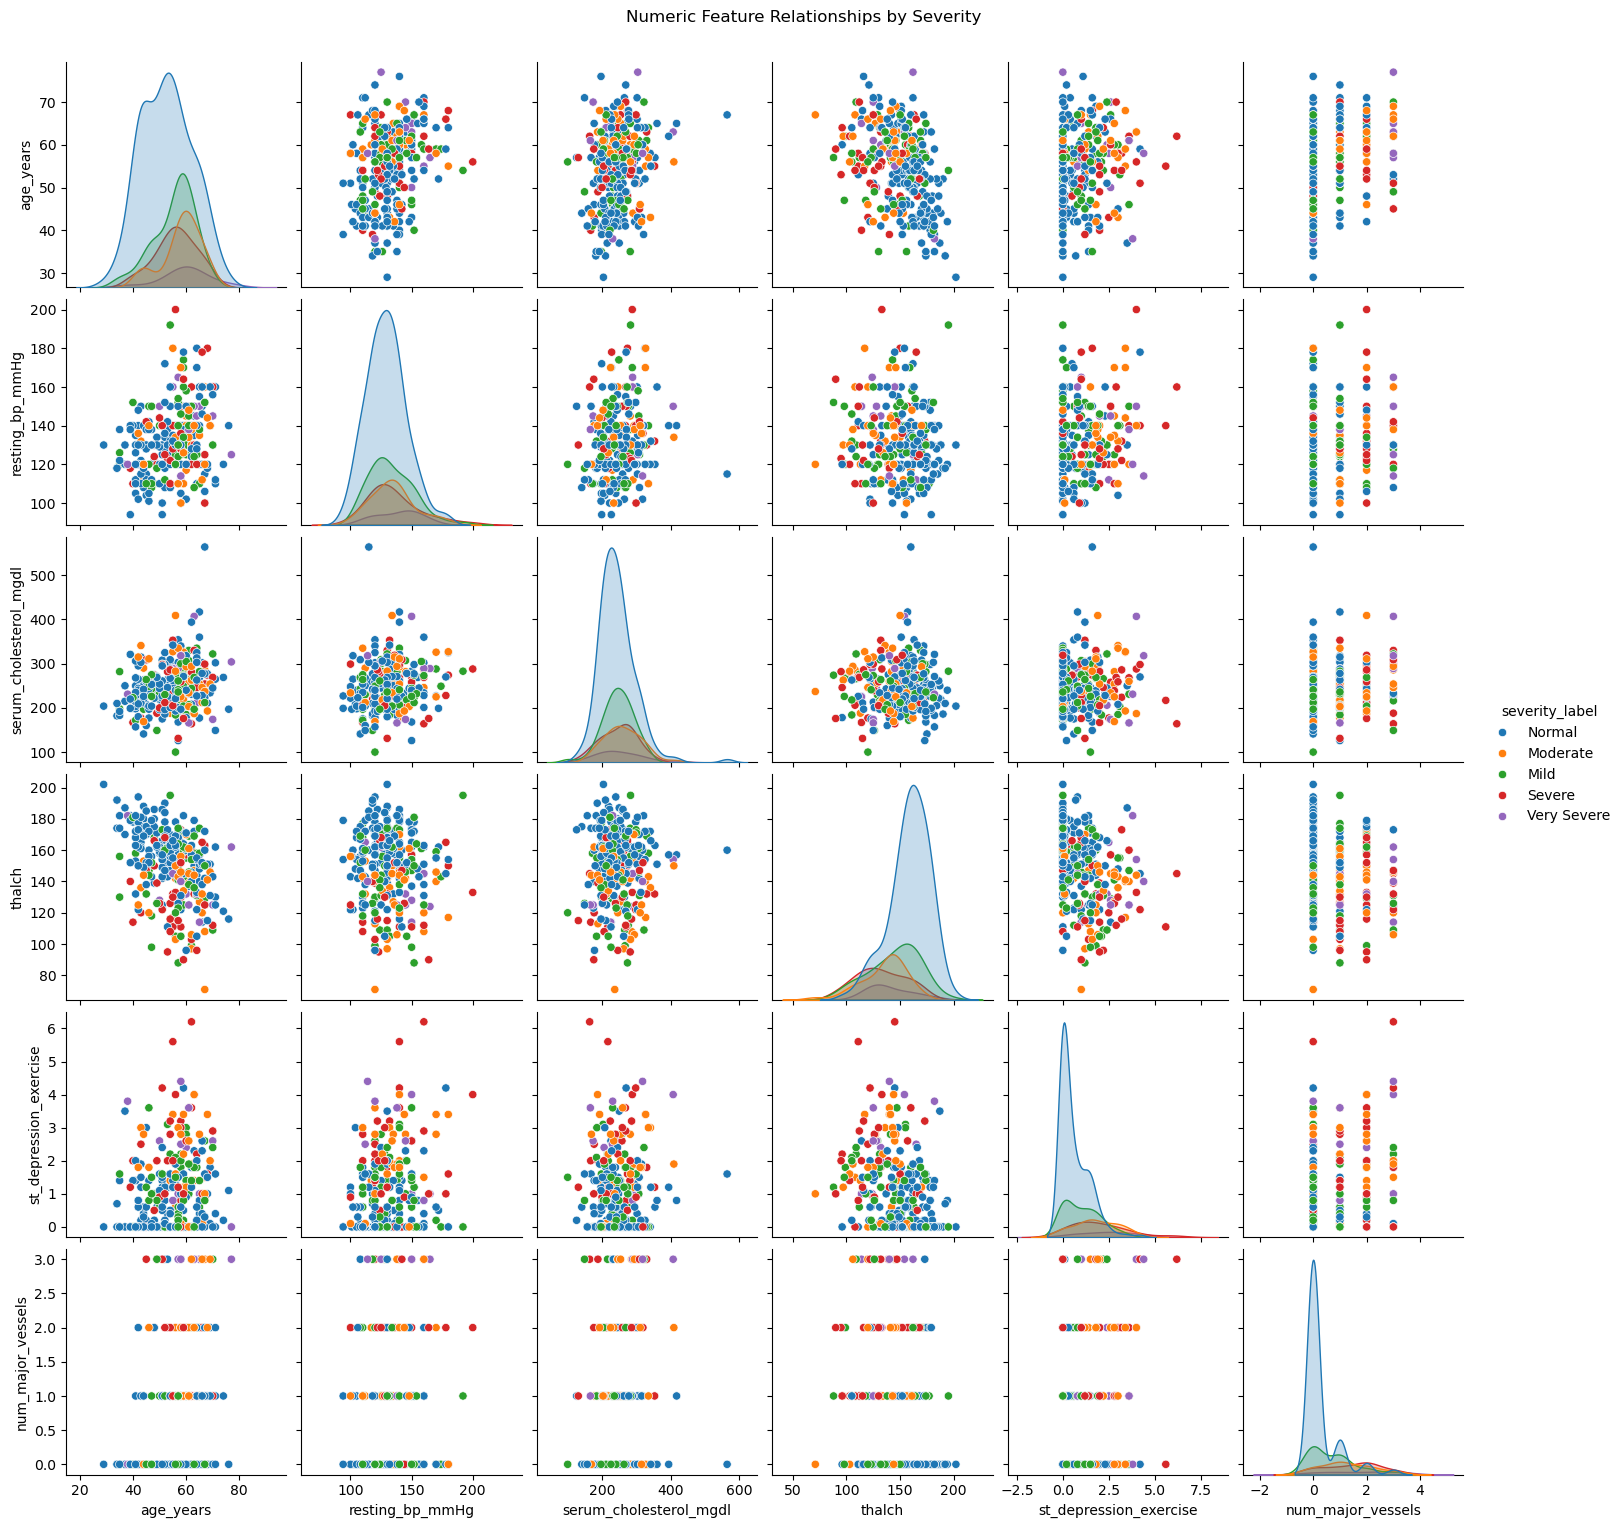

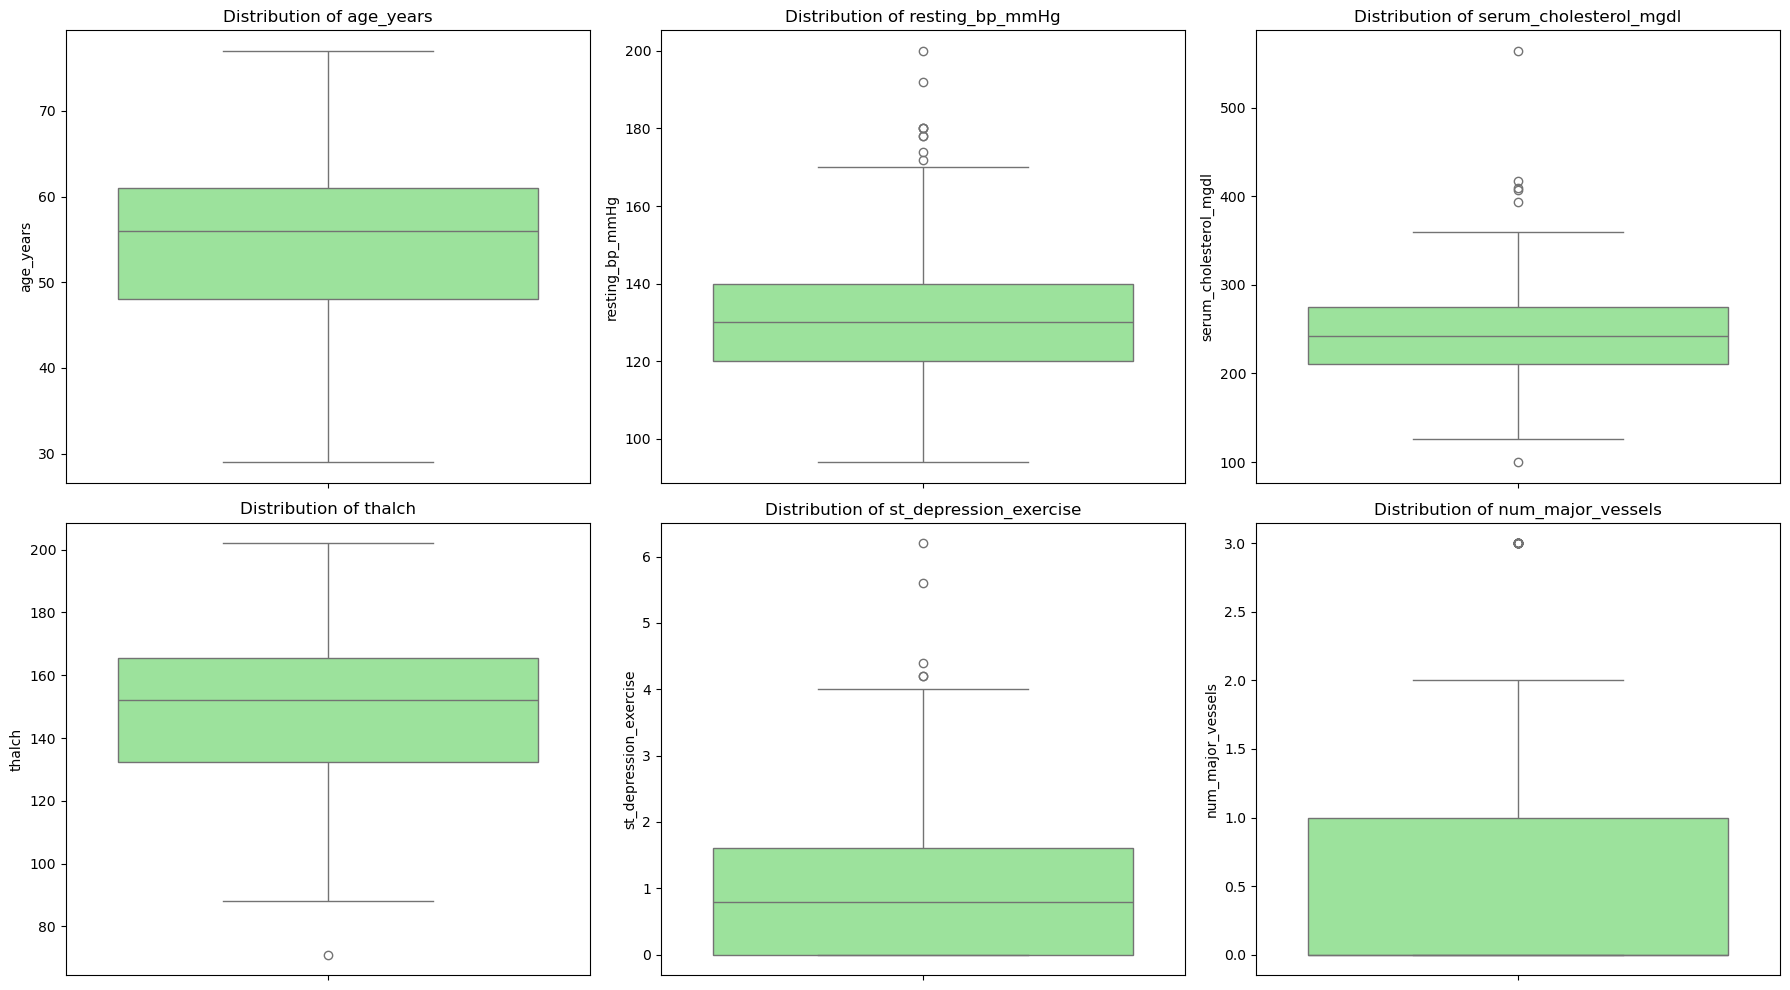

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx")

# Check the shape and first few rows
print(df.shape)
print(df.head())

# 1. Pairplot for Numeric Relationships
numeric_cols = ['age_years', 'resting_bp_mmHg', 'serum_cholesterol_mgdl', 'thalch', 'st_depression_exercise', 'num_major_vessels']
sns.pairplot(df[numeric_cols + ['severity_label']], hue='severity_label', diag_kind='kde')
plt.suptitle("Numeric Feature Relationships by Severity", y=1.02)
plt.show()

# 2. Boxplots for Outlier Detection
fig, axes = plt.subplots(2, 3, figsize=(18,10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], color="lightgreen", ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

severity_label
Normal         160
Mild            56
Moderate        35
Severe          35
Very Severe     13
Name: count, dtype: int64
severity_label
Normal         0.535117
Mild           0.187291
Moderate       0.117057
Severe         0.117057
Very Severe    0.043478
Name: proportion, dtype: float64


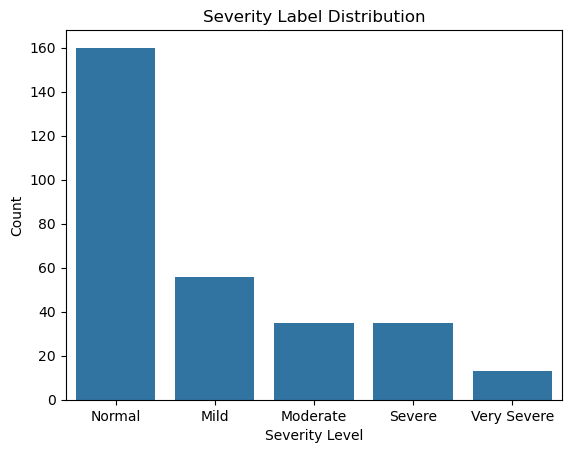

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class distribution (counts)
print(df["severity_label"].value_counts())

# Check relative proportions (percentages)
print(df["severity_label"].value_counts(normalize=True))

# Quick visualization
sns.countplot(x="severity_label", data=df,
              order=df["severity_label"].value_counts().index)  # keeps bars sorted
plt.title("Severity Label Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()



In [128]:
# Combine Severe and Very Severe into one class
df['severity_label'] = df['severity_label'].replace({
    'Very Severe': 'Severe'
})


severity_label
Normal      160
Mild         56
Severe       48
Moderate     35
Name: count, dtype: int64
severity_label
Normal      0.535117
Mild        0.187291
Severe      0.160535
Moderate    0.117057
Name: proportion, dtype: float64


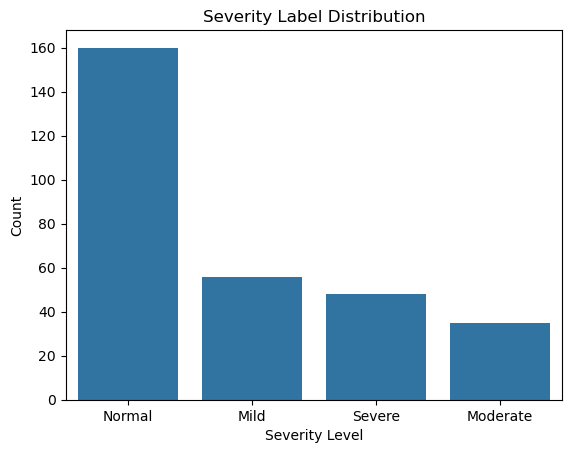

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class distribution (counts)
print(df["severity_label"].value_counts())

# Check relative proportions (percentages)
print(df["severity_label"].value_counts(normalize=True))

# Quick visualization
sns.countplot(x="severity_label", data=df,
              order=df["severity_label"].value_counts().index)  # keeps bars sorted
plt.title("Severity Label Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()



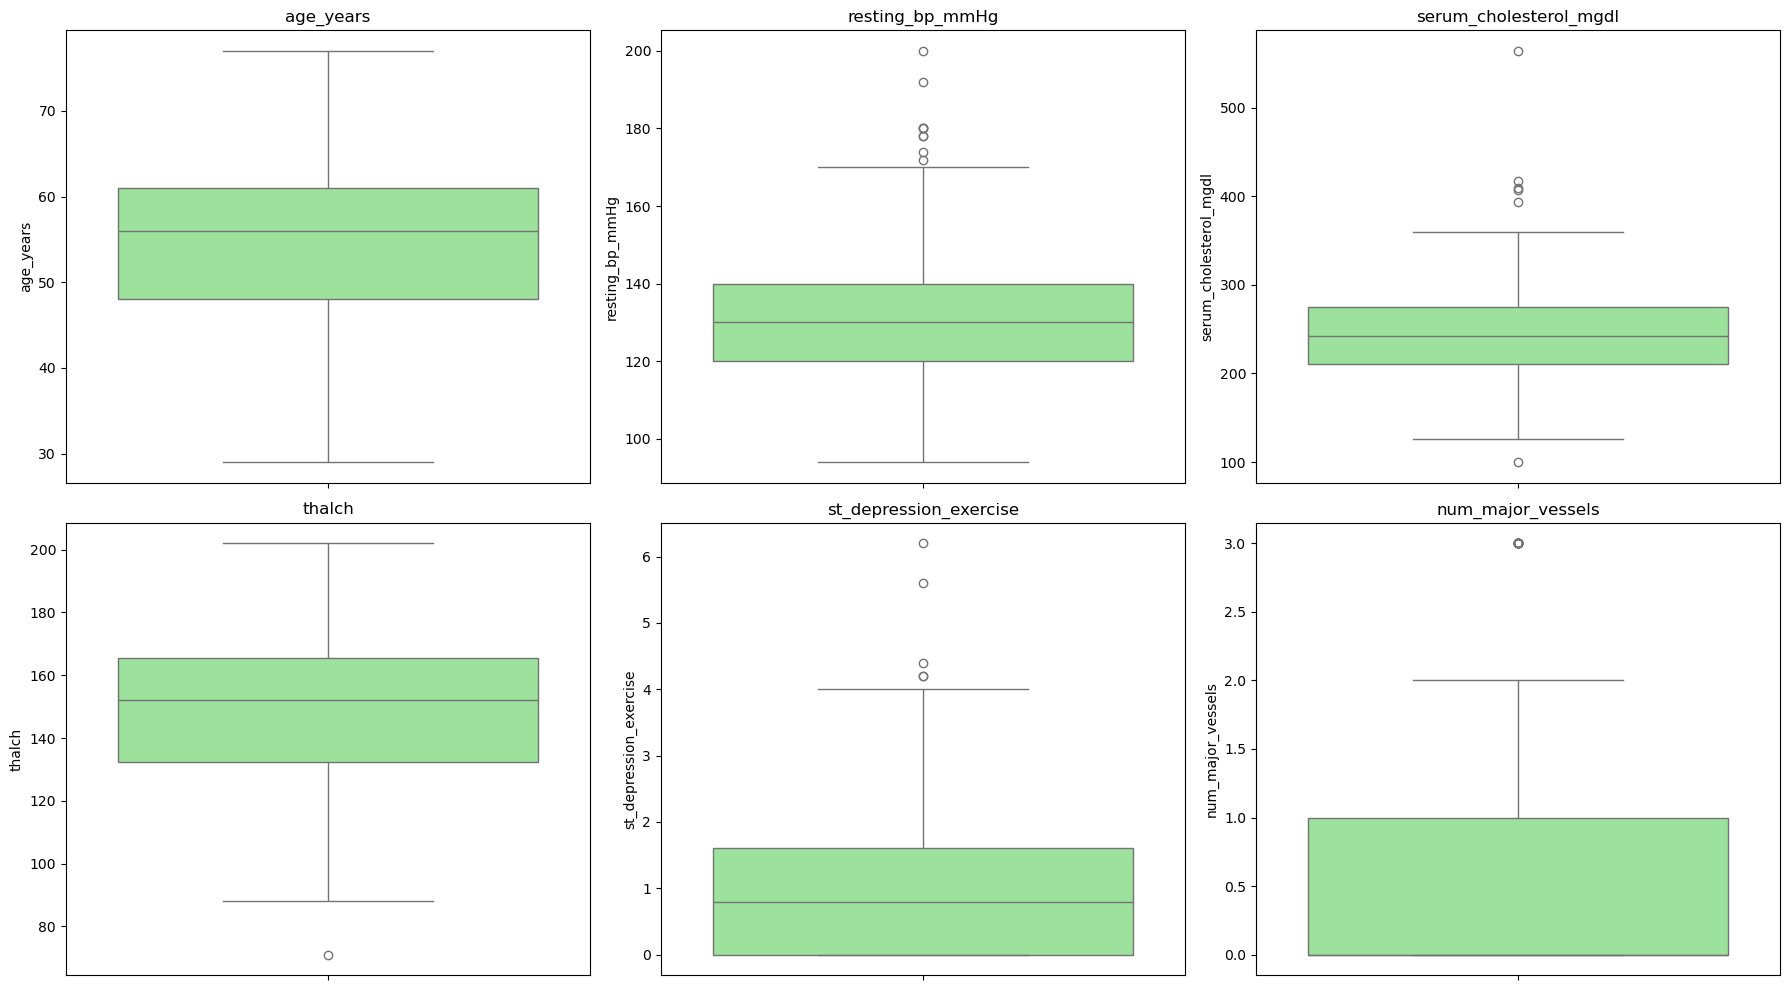

In [130]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], color="lightgreen", ax=ax)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()


In [131]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                  0
resting_bp_mmHg            9
serum_cholesterol_mgdl     6
thalch                     1
st_depression_exercise     5
num_major_vessels         20
dtype: int64


In [132]:
#Age years has no outliers (Clean Distribution)
#resting_bp_mmHg has 9 Outliers (Moderate Distribution)
#serum_cholesterol_mgdl has 6 Outliers (Moderate Distribution)
#thalch has 1 outlier (Minimal Distribution)
#st_depression_exercise has 5 outliers (Moderate Distribution)
#num_major_vessels has 20 outliers (High Distribution)

## Data Preprocessing
Handling missing values, feature selection, scaling, and target label adjustments.


<Axes: xlabel='num_major_vessels', ylabel='count'>

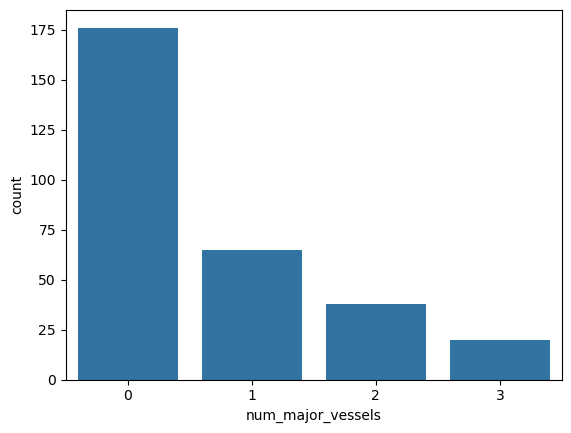

In [133]:
# shows countplot for num_major_vessels

import seaborn as sns
sns.countplot(x='num_major_vessels', data=df)


In [134]:
# Outliers for the variable number of major vessels were not removed. 
# This choice was made because the values represent genuine clinical conditions rather than data errors. 
# Rare but severe cases are medically meaningful, and excluding them would reduce the model’s ability to 
# detect high‑risk patients, which is central to predicting heart disease severity.


In [135]:
from sklearn.model_selection import train_test_split

# Features Selection & Encoding
strong_features = ['thalch', 'num_major_vessels', 'st_depression_exercise', 'age_years', 
                   'serum_cholesterol_mgdl', 'resting_bp_mmHg', 'chest_pain_type', 'thal_defect_type']

X = pd.get_dummies(df[strong_features], drop_first=True)
y = df['severity_label']

# THE SPLIT: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (239, 11)
Testing Features Shape: (60, 11)


In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Model 1: Logistic Regression ---
logr = LogisticRegression(max_iter=10000)
logr.fit(X_train, y_train)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, logr.predict(X_test)):.4f}")



Logistic Regression Accuracy: 0.6333


In [137]:
# --- Model 2: Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt.predict(X_test)):.4f}")

Decision Tree Accuracy: 0.5333


In [138]:
# --- Model 3: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

Random Forest Accuracy: 0.6833


## Feature Importance:


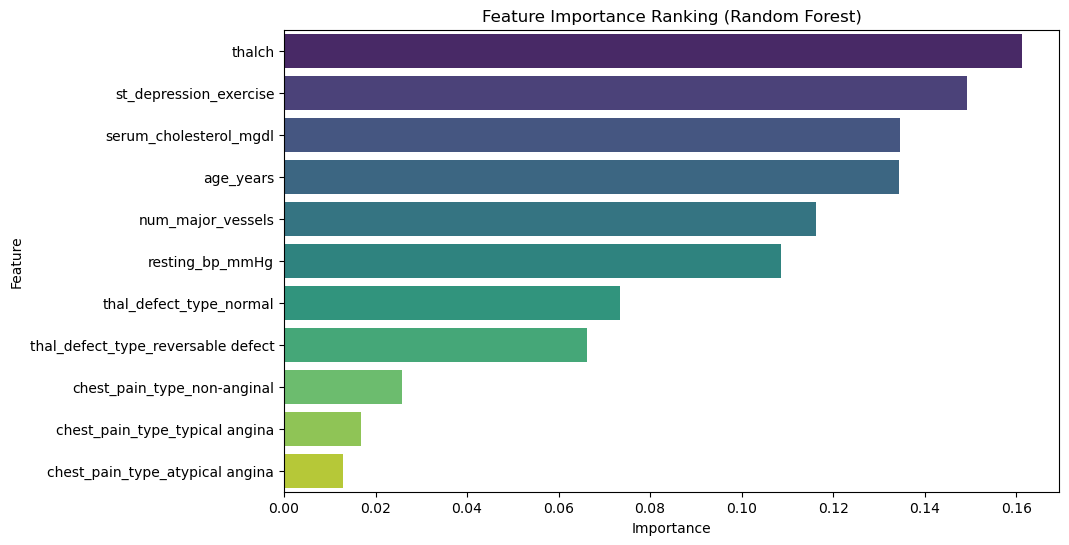

In [139]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# Fixed: Assigned 'y' to 'hue' and set 'legend=False' to satisfy new Seaborn requirements
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette="viridis", legend=False)
plt.title("Feature Importance Ranking (Random Forest)")
plt.show()

In [140]:
import pandas as pd

# Get feature importances directly
importances = rf.feature_importances_
features = X_train.columns  

importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance.head(15))


                               Feature  Importance
0                               thalch    0.161299
2               st_depression_exercise    0.149323
4               serum_cholesterol_mgdl    0.134701
3                            age_years    0.134471
1                    num_major_vessels    0.116290
5                      resting_bp_mmHg    0.108687
9              thal_defect_type_normal    0.073527
10  thal_defect_type_reversable defect    0.066258
7          chest_pain_type_non-anginal    0.025731
8       chest_pain_type_typical angina    0.016899
6      chest_pain_type_atypical angina    0.012813


## Now Another Run of Models with Feature Importance
This section explores the accuracy difference for Models with Feature Importance


In [141]:
cols_to_drop = [
    "sex_male_female",
    "chest_pain_type",
    "fasting_blood_sugar_gt120",
    "resting_ecg_result",
    "exercise_induced_angina",
    "st_slope_peak_exercise",
    "thal_defect_type"
]

df_clean = df.drop(cols_to_drop, axis=1)


In [142]:
print(df_clean.columns.tolist())


['age_years', 'resting_bp_mmHg', 'serum_cholesterol_mgdl', 'thalch', 'st_depression_exercise', 'num_major_vessels', 'severity_label']


In [143]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Drop unwanted columns
cols_to_drop = ["sex_male_female", "chest_pain_type", "fasting_blood_sugar_gt120", 
                "resting_ecg_result", "exercise_induced_angina", "st_slope_peak_exercise", "thal_defect_type"]

df_clean = df.drop(cols_to_drop, axis=1)

# Features and Target
X = df_clean.drop('severity_label', axis=1)
y = df_clean['severity_label']

# Encoding and Split
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=2025)

In [144]:
df_clean

,age_years,resting_bp_mmHg,serum_cholesterol_mgdl,thalch,st_depression_exercise,num_major_vessels,severity_label
0,63,145,233,150,2.3,0,Normal
1,67,160,286,108,1.5,3,Moderate
2,67,120,229,129,2.6,2,Mild
3,37,130,250,187,3.5,0,Normal
4,41,130,204,172,1.4,0,Normal
...,...,...,...,...,...,...,...
294,68,144,193,141,3.4,2,Moderate
295,57,130,131,115,1.2,1,Severe
296,57,130,236,174,0.0,1,Mild
297,47,150,226,98,1.5,0,Mild


## Training Once Again after FI
Training the 3 models again

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Model 1: Logistic Regression ---
newlogr = LogisticRegression(max_iter=10000)
newlogr.fit(X_train, y_train)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, newlogr.predict(X_test)):.4f}")



Logistic Regression Accuracy: 0.6000


In [146]:
# --- Model 2: Decision Tree ---
newdt = DecisionTreeClassifier(random_state=42)
newdt.fit(X_train, y_train)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, newdt.predict(X_test)):.4f}")

Decision Tree Accuracy: 0.5333


In [147]:
# --- Model 3: Random Forest ---
newrf = RandomForestClassifier(n_estimators=100, random_state=42)
newrf.fit(X_train, y_train)
print(f"Random Forest Accuracy: {accuracy_score(y_test, newrf.predict(X_test)):.4f}")

Random Forest Accuracy: 0.5667


                 Model  Accuracy (Initial - 8 Features)  \
0  Logistic Regression                         0.633333   
1        Decision Tree                         0.533333   
2        Random Forest                         0.683333   
3  Tuned Random Forest                              NaN   

   Accuracy (Cleaned - After FI)  
0                       0.600000  
1                       0.533333  
2                       0.566667  
3                       0.616700  


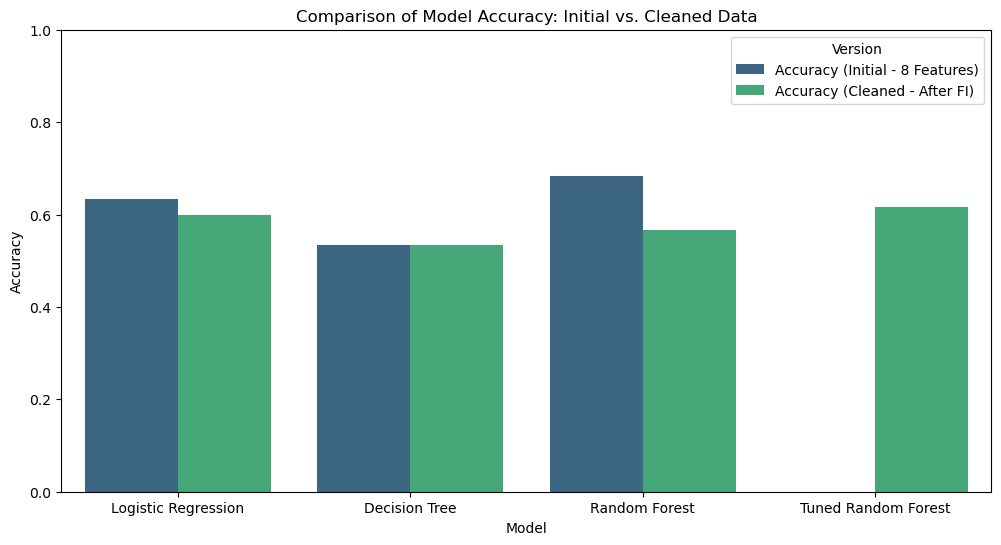

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. SET UP INITIAL DATA (8 FEATURES) ---
strong_features = ['thalch', 'num_major_vessels', 'st_depression_exercise', 'age_years', 
                   'serum_cholesterol_mgdl', 'resting_bp_mmHg', 'chest_pain_type', 'thal_defect_type']
X_init = pd.get_dummies(df[strong_features], drop_first=True)
y = df['severity_label']
X_train_init, X_test_init, y_train_init, y_test_init = train_test_split(X_init, y, test_size=0.2, random_state=2025)

# Train Initial Models
rf_init = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_init, y_train_init)
dt_init = DecisionTreeClassifier(random_state=42).fit(X_train_init, y_train_init)
logr_init = LogisticRegression(max_iter=10000).fit(X_train_init, y_train_init)

# --- 2. SET UP CLEANED DATA (AFTER DROPPING COLUMNS) ---
cols_to_drop = ["sex_male_female", "chest_pain_type", "fasting_blood_sugar_gt120", 
                "resting_ecg_result", "exercise_induced_angina", "st_slope_peak_exercise", "thal_defect_type"]
df_clean = df.drop(cols_to_drop, axis=1)
X_clean = pd.get_dummies(df_clean.drop('severity_label', axis=1), drop_first=True)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y, test_size=0.2, random_state=2025)

# Train Cleaned Models
rf_clean = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_clean, y_train_clean)
dt_clean = DecisionTreeClassifier(random_state=42).fit(X_train_clean, y_train_clean)
logr_clean = LogisticRegression(max_iter=10000).fit(X_train_clean, y_train_clean)

# --- 3. CREATE COMPARISON TABLE ---
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy (Initial - 8 Features)': [
        accuracy_score(y_test_init, logr_init.predict(X_test_init)),
        accuracy_score(y_test_init, dt_init.predict(X_test_init)),
        accuracy_score(y_test_init, rf_init.predict(X_test_init))
    ],
    'Accuracy (Cleaned - After FI)': [
        accuracy_score(y_test_clean, logr_clean.predict(X_test_clean)),
        accuracy_score(y_test_clean, dt_clean.predict(X_test_clean)),
        accuracy_score(y_test_clean, rf_clean.predict(X_test_clean))
    ]
})

# Add the Tuned result from your previous RandomSearch
tuned_row = pd.DataFrame({
    'Model': ['Tuned Random Forest'],
    'Accuracy (Initial - 8 Features)': [np.nan],
    'Accuracy (Cleaned - After FI)': [0.6167]
})

final_comparison = pd.concat([results, tuned_row], ignore_index=True)
print(final_comparison)

# --- 4. VISUALIZATION ---
plot_df = final_comparison.melt(id_vars='Model', var_name='Version', value_name='Accuracy')
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Accuracy', hue='Version', palette='viridis')
plt.title("Comparison of Model Accuracy: Initial vs. Cleaned Data")
plt.ylim(0, 1.0)
plt.show()

## Further Tuning
advancement to using the Best RF Model
Using optuna to check if we can get it higher than the original 0.61670 Accuracy

In [149]:
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ensure target is consolidated
df['severity_label'] = df['severity_label'].replace({'Very Severe': 'Severe'})

# Features from the best initial run
strong_features = ['thalch', 'num_major_vessels', 'st_depression_exercise', 'age_years', 
                   'serum_cholesterol_mgdl', 'resting_bp_mmHg', 'chest_pain_type', 'thal_defect_type']

X = pd.get_dummies(df[strong_features], drop_first=True)
y = df['severity_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

In [150]:
def objective(trial):
    # Suggest hyperparameters
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 32, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }
    
    # Initialize model with suggested params
    model = RandomForestClassifier(**param)
    
    # Use 5-fold cross-validation to get a stable score
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5).mean()
    return score

# Run the optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Trial 50 different combinations

print(f"Best Accuracy from Optimization: {study.best_value:.4f}")
print("Best Hyperparameters:", study.best_params)

[I 2026-02-03 23:20:27,955] A new study created in memory with name: no-name-461092df-963f-4b7f-b348-85fe1255a321
[I 2026-02-03 23:20:28,331] Trial 0 finished with value: 0.5608156028368795 and parameters: {'n_estimators': 226, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 0.5608156028368795.
[I 2026-02-03 23:20:28,757] Trial 1 finished with value: 0.5943262411347519 and parameters: {'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5943262411347519.
[I 2026-02-03 23:20:29,038] Trial 2 finished with value: 0.6195035460992908 and parameters: {'n_estimators': 165, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 2 with value: 0.6195035460992908.
[I 2026-02-03 23:20:29,697] Trial 3 finished with value: 0.6110815602836879 and parameters: {'n_estimators': 443, 'max_depth': 2, 'min_s

Best Accuracy from Optimization: 0.6279
Best Hyperparameters: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 9, 'criterion': 'entropy'}


## Training with initial RF model without FI

In [151]:
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ensure we are using the 8-feature set
strong_features = ['thalch', 'num_major_vessels', 'st_depression_exercise', 'age_years', 
                   'serum_cholesterol_mgdl', 'resting_bp_mmHg', 'chest_pain_type', 'thal_defect_type']

X = pd.get_dummies(df[strong_features], drop_first=True)
y = df['severity_label']

X_train_init, X_test_init, y_train_init, y_test_init = train_test_split(X, y, test_size=0.2, random_state=2025)

In [152]:
def objective(trial):
    # Hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }
    
    model = RandomForestClassifier(**params)
    
    # Use Cross-Validation for a more stable accuracy metric
    score = cross_val_score(model, X_train_init, y_train_init, n_jobs=-1, cv=5).mean()
    return score

# Create and run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best Cross-Validation Accuracy: {study.best_value:.4f}")
print("Best Parameters:", study.best_params)

[I 2026-02-03 23:23:28,418] A new study created in memory with name: no-name-fdedd8e3-80ee-4f5b-936a-747e10585215
[I 2026-02-03 23:23:28,814] Trial 0 finished with value: 0.5813829787234043 and parameters: {'n_estimators': 233, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5813829787234043.
[I 2026-02-03 23:23:29,346] Trial 1 finished with value: 0.5816489361702127 and parameters: {'n_estimators': 320, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 1 with value: 0.5816489361702127.
[I 2026-02-03 23:23:29,741] Trial 2 finished with value: 0.5941489361702128 and parameters: {'n_estimators': 248, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 2 with value: 0.5941489361702128.
[I 2026-02-03 23:23:29,981] Trial 3 finished with value: 0.5941489361702128 and parameters: {'n_estimators': 148, 'max_depth': 14, 'min_sam

Best Cross-Validation Accuracy: 0.6194
Best Parameters: {'n_estimators': 366, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'entropy'}
